In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ( accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
)
import warnings
warnings.filterwarnings("ignore")
print("Libraries imported successfully!")

Libraries imported successfully!


In [47]:
df = pd.read_csv("hospital_patient_waiting_times.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10010, 9)


In [48]:
df.head()

,Patient_ID,Department,Appointment_Time,Registration_Time,Consultation_Time,Discharge_Time,Doctor,Day,Appointment_Type
0,P00001,Gynecology,2026-04-13 15:20:00,2026-04-13 15:25:00,2026-04-13 15:43:00,2026-04-13 15:48:00,Dr. Nandhini,Monday,Follow-up
1,P00002,Dermatology,2026-04-14 14:50:00,2026-04-14 14:57:00,2026-04-14 15:07:00,2026-04-14 15:19:00,Dr. Hari,Tuesday,Follow-up
2,P00003,Gynecology,2026-06-19 09:30:00,2026-06-19 09:36:00,2026-06-19 10:01:00,2026-06-19 10:28:00,Dr. Nandhini,Friday,Regular
3,P00004,General Medicine,2026-05-11 16:40:00,2026-05-11 16:51:00,2026-05-11 17:03:00,2026-05-11 17:21:00,Dr. Karthik,Monday,Regular
4,P00005,Pediatrics,2026-01-09 09:10:00,2026-01-09 09:19:00,2026-01-09 09:26:00,2026-01-09 09:45:00,Dr. Naveen,Friday,Regular


In [49]:
df.tail()

,Patient_ID,Department,Appointment_Time,Registration_Time,Consultation_Time,Discharge_Time,Doctor,Day,Appointment_Type
10005,P06341,Orthopedics,2026-03-04 10:00:00,2026-03-04 10:13:00,2026-03-04 10:41:00,2026-03-04 10:53:00,Dr. Divya,Wednesday,Regular
10006,P00577,Gynecology,2026-01-09 13:50:00,2026-01-09 14:00:00,2026-01-09 14:17:00,2026-01-09 14:31:00,Dr. Priya,Friday,Follow-up
10007,P05203,Cardiology,2026-03-30 15:30:00,2026-03-30 15:44:00,2026-03-30 16:38:00,2026-03-30 17:06:00,Dr. Rajesh,Monday,Regular
10008,P06364,Neurology,2026-06-07 09:30:00,2026-06-07 09:39:00,2026-06-07 10:14:00,2026-06-07 10:39:00,Dr. Swetha,Sunday,Regular
10009,P00440,Dermatology,2026-05-07 12:40:00,2026-05-07 12:53:00,2026-05-07 13:16:00,2026-05-07 13:28:00,Dr. Kavya,Thursday,Follow-up


In [50]:
print(df.columns.tolist())

['Patient_ID', 'Department', 'Appointment_Time', 'Registration_Time', 'Consultation_Time', 'Discharge_Time', 'Doctor', 'Day', 'Appointment_Type']


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10010 entries, 0 to 10009
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         10010 non-null  object
 1   Department         10010 non-null  object
 2   Appointment_Time   10010 non-null  object
 3   Registration_Time  9980 non-null   object
 4   Consultation_Time  10010 non-null  object
 5   Discharge_Time     10010 non-null  object
 6   Doctor             9960 non-null   object
 7   Day                10010 non-null  object
 8   Appointment_Type   9970 non-null   object
dtypes: object(9)
memory usage: 704.0+ KB


In [52]:
print(df.isnull().sum())

Patient_ID            0
Department            0
Appointment_Time      0
Registration_Time    30
Consultation_Time     0
Discharge_Time        0
Doctor               50
Day                   0
Appointment_Type     40
dtype: int64


In [53]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 10


In [54]:
df=df.drop_duplicates()
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 10000


In [55]:
time_columns=[ "Appointment_Time","Registration_Time","Consultation_Time","Discharge_Time"]
for col in time_columns:
    df[col]=pd.to_datetime(df[col], errors="coerce")
print("Timestamp conversion completed.")

Timestamp conversion completed.


In [56]:
def fill_doctor(group):
    mode=group["Doctor"].mode()

    if len(mode) > 0:
        group["Doctor"]=group["Doctor"].fillna(mode.iloc[0])

    return group

df=df.groupby("Department",group_keys=False).apply(fill_doctor)

print("Missing Doctor values:")
print(df["Doctor"].isnull().sum())

Missing Doctor values:
0


In [57]:
most_common_type=df["Appointment_Type"].mode()[0]

df["Appointment_Type"]=df["Appointment_Type"].fillna(
    most_common_type
)

print("Missing Appointment_Type values:",
      df["Appointment_Type"].isnull().sum())

Missing Appointment_Type values: 0


In [58]:
registration_wait = (
    df["Registration_Time"] - df["Appointment_Time"]
).dt.total_seconds() / 60

df["Registration_Wait_Temp"] = registration_wait

department_median = df.groupby(
    "Department"
)["Registration_Wait_Temp"].transform("median")

missing_registration = df["Registration_Time"].isna()

df.loc[missing_registration, "Registration_Time"] = (
    df.loc[missing_registration, "Appointment_Time"]
    + pd.to_timedelta(
        department_median[missing_registration],
        unit="m"
    )
)

df.drop(columns=["Registration_Wait_Temp"], inplace=True)

print(
    "Missing Registration_Time values:",
    df["Registration_Time"].isnull().sum()
)

Missing Registration_Time values: 0


In [59]:
print("Remaining missing values:")
print(df.isnull().sum())

print("\nTotal missing values:",
      df.isnull().sum().sum())

print("\nDuplicate rows:",
      df.duplicated().sum())

Remaining missing values:
Patient_ID           0
Department           0
Appointment_Time     0
Registration_Time    0
Consultation_Time    0
Discharge_Time       0
Doctor               0
Day                  0
Appointment_Type     0
dtype: int64

Total missing values: 0

Duplicate rows: 0


In [60]:
invalid_registration = (
    df["Registration_Time"] < df["Appointment_Time"]
)

invalid_consultation = (
    df["Consultation_Time"] < df["Registration_Time"]
)

invalid_discharge = (
    df["Discharge_Time"] < df["Consultation_Time"]
)

print("Invalid registration timestamps:",
      invalid_registration.sum())

print("Invalid consultation timestamps:",
      invalid_consultation.sum())

print("Invalid discharge timestamps:",
      invalid_discharge.sum())

Invalid registration timestamps: 0
Invalid consultation timestamps: 4
Invalid discharge timestamps: 0


TOTAL WAITING TIME


In [61]:
df["Registration_Waiting_Min"] = (
    df["Registration_Time"] -
    df["Appointment_Time"]
).dt.total_seconds() / 60

df["Doctor_Waiting_Min"] = (
    df["Consultation_Time"] -
    df["Registration_Time"]
).dt.total_seconds() / 60

df["Total_Waiting_Min"] = (
    df["Consultation_Time"] -
    df["Appointment_Time"]
).dt.total_seconds() / 60

df["Total_Hospital_Time_Min"] = (
    df["Discharge_Time"] -
    df["Appointment_Time"]
).dt.total_seconds() / 60

In [62]:
display(
    df[
        [
            "Patient_ID",
            "Registration_Waiting_Min",
            "Doctor_Waiting_Min",
            "Total_Waiting_Min",
            "Total_Hospital_Time_Min"
        ]
    ].head(10)
)

,Patient_ID,Registration_Waiting_Min,Doctor_Waiting_Min,Total_Waiting_Min,Total_Hospital_Time_Min
0,P00001,5.0,18.0,23.0,28.0
1,P00002,7.0,10.0,17.0,29.0
2,P00003,6.0,25.0,31.0,58.0
3,P00004,11.0,12.0,23.0,41.0
4,P00005,9.0,7.0,16.0,35.0
5,P00006,3.0,35.0,38.0,61.0
6,P00007,8.0,37.0,45.0,67.0
7,P00008,15.0,50.0,65.0,92.0
8,P00009,2.0,20.0,22.0,36.0
9,P00010,7.0,25.0,32.0,43.0


In [63]:
df["Appointment_Hour"] = df["Appointment_Time"].dt.hour

df["Appointment_Minute"] = df["Appointment_Time"].dt.minute

df["Is_Weekend"] = df["Day"].isin(
    ["Saturday", "Sunday"]
)

df["Day_Type"] = np.where(
    df["Is_Weekend"],
    "Weekend",
    "Weekday"
)

print(df[
    [
        "Appointment_Hour",
        "Appointment_Minute",
        "Day_Type"
    ]
].head())

   Appointment_Hour  Appointment_Minute Day_Type
0                15                  20  Weekday
1                14                  50  Weekday
2                 9                  30  Weekday
3                16                  40  Weekday
4                 9                  10  Weekday


In [64]:
print("Waiting Time Statistics")

display(
    df[
        [
            "Registration_Waiting_Min",
            "Doctor_Waiting_Min",
            "Total_Waiting_Min",
            "Total_Hospital_Time_Min"
        ]
    ].describe()
)

Waiting Time Statistics


,Registration_Waiting_Min,Doctor_Waiting_Min,Total_Waiting_Min,Total_Hospital_Time_Min
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,13.533600,29.902800,43.436400,60.431500
std,6.274042,15.221804,18.515805,20.819089
min,2.000000,-4.000000,7.000000,13.000000
25%,9.000000,18.000000,29.000000,45.000000
50%,13.000000,29.000000,43.000000,59.000000
75%,18.000000,40.000000,56.000000,74.000000
max,39.000000,90.000000,111.000000,142.000000


In [65]:
department_analysis = (
    df.groupby("Department")
    .agg(
        Patients=("Patient_ID", "count"),
        Avg_Registration_Wait=("Registration_Waiting_Min", "mean"),
        Avg_Doctor_Wait=("Doctor_Waiting_Min", "mean"),
        Avg_Total_Wait=("Total_Waiting_Min", "mean"),
        Median_Total_Wait=("Total_Waiting_Min", "median")
    )
    .sort_values(
        "Avg_Total_Wait",
        ascending=False
    )
)

display(department_analysis)

,Patients,Avg_Registration_Wait,Avg_Doctor_Wait,Avg_Total_Wait,Median_Total_Wait
Department,,,,,
Neurology,1294,13.553323,39.696291,53.249614,53.0
Cardiology,1265,13.494071,37.892490,51.386561,51.0
Orthopedics,1230,13.412195,32.668293,46.080488,45.5
Gynecology,1209,13.508685,30.717122,44.225806,43.0
Pediatrics,1218,13.524631,28.711823,42.236453,42.0
ENT,1212,13.524752,25.514026,39.038779,38.0
General Medicine,1234,13.555105,22.779579,36.334684,35.0
Dermatology,1338,13.682362,21.228700,34.911061,34.0


In [66]:
doctor_analysis = (
    df.groupby("Doctor")
    .agg(
        Patients=("Patient_ID", "count"),
        Avg_Waiting=("Total_Waiting_Min", "mean"),
        Median_Waiting=("Total_Waiting_Min", "median")
    )
    .sort_values(
        "Avg_Waiting",
        ascending=False
    )
)

display(doctor_analysis)

,Patients,Avg_Waiting,Median_Waiting
Doctor,,,
Dr. Ramesh,635,53.862992,54.0
Dr. Swetha,659,52.658574,52.0
Dr. Meena,621,51.705314,51.0
Dr. Rajesh,644,51.079193,50.0
Dr. Suresh,592,46.880068,46.0
Dr. Divya,638,45.338558,45.0
Dr. Nandhini,585,45.232479,45.0
Dr. Naveen,574,42.844948,42.5
Dr. Anitha,644,41.694099,41.0


In [67]:
appointment_analysis = (
    df.groupby("Appointment_Type")
    .agg(
        Patients=("Patient_ID", "count"),
        Avg_Waiting=("Total_Waiting_Min", "mean"),
        Median_Waiting=("Total_Waiting_Min", "median")
    )
    .sort_values(
        "Avg_Waiting",
        ascending=False
    )
)

display(appointment_analysis)

,Patients,Avg_Waiting,Median_Waiting
Appointment_Type,,,
Emergency,803,62.170610,62.0
Walk-in,1235,57.188664,57.0
Follow-up,2178,39.562902,39.0
Regular,5784,39.357711,39.0


In [68]:
hour_analysis = (
    df.groupby("Appointment_Hour")
    .agg(
        Patients=("Patient_ID", "count"),
        Avg_Waiting=("Total_Waiting_Min", "mean")
    )
)

display(hour_analysis)

,Patients,Avg_Waiting
Appointment_Hour,,
9,624,35.743590
10,1021,55.836435
11,1523,55.707814
12,1818,55.330583
13,1873,35.483716
14,1144,32.899476
15,860,32.658140
16,662,32.959215
17,475,32.871579


In [69]:
weekend_analysis = (
    df.groupby("Day_Type")
    .agg(
        Patients=("Patient_ID", "count"),
        Avg_Registration_Wait=("Registration_Waiting_Min", "mean"),
        Avg_Doctor_Wait=("Doctor_Waiting_Min", "mean"),
        Avg_Total_Wait=("Total_Waiting_Min", "mean")
    )
)

display(weekend_analysis)

,Patients,Avg_Registration_Wait,Avg_Doctor_Wait,Avg_Total_Wait
Day_Type,,,,
Weekday,7183,12.705276,27.337463,40.042740
Weekend,2817,15.645722,36.444089,52.089812


VISUALIZATION 1 — Department Waiting Time

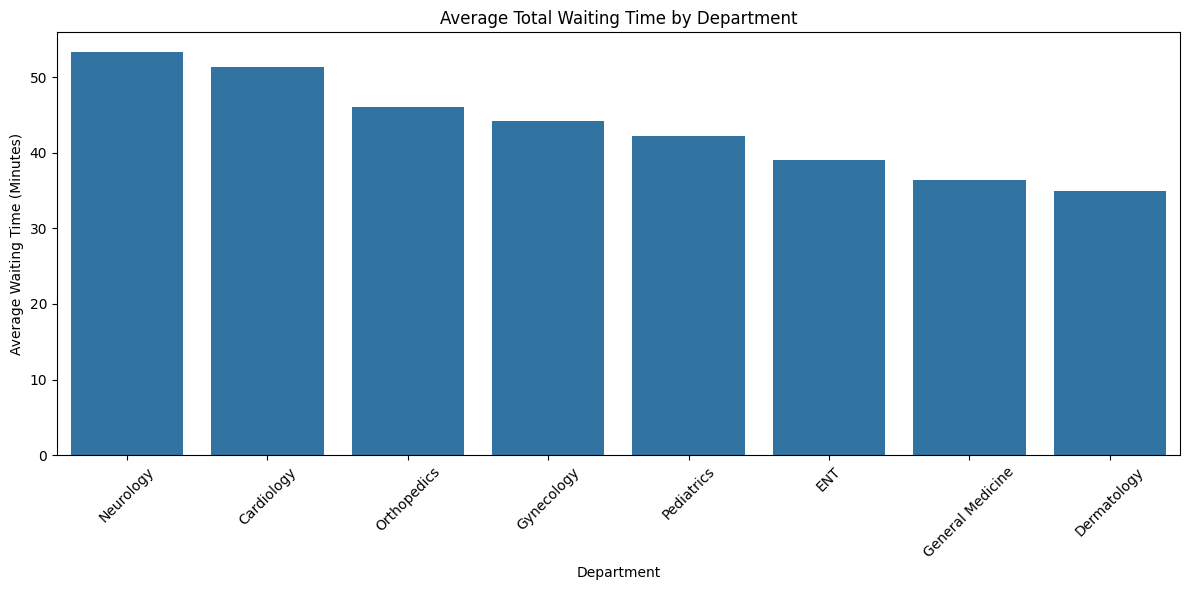

In [70]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=department_analysis.reset_index(),
    x="Department",
    y="Avg_Total_Wait"
)

plt.title("Average Total Waiting Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Waiting Time (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

VISUALIZATION 2 — Registration vs Doctor Waiting

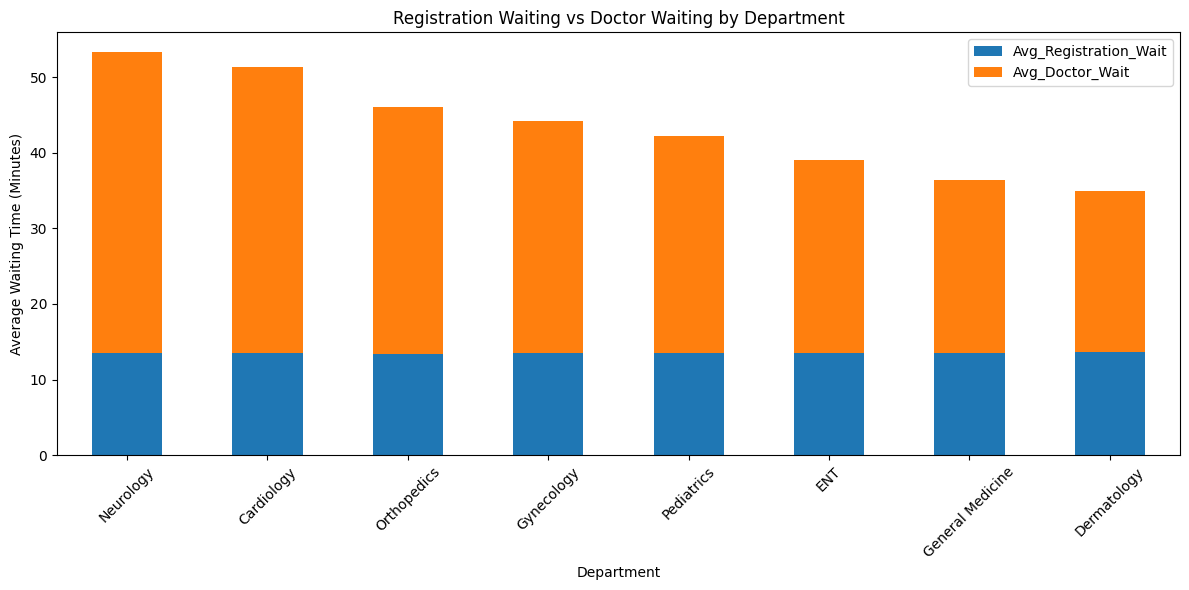

In [71]:
plot_data = department_analysis[
    [
        "Avg_Registration_Wait",
        "Avg_Doctor_Wait"
    ]
].reset_index()

plot_data.set_index("Department").plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title(
    "Registration Waiting vs Doctor Waiting by Department"
)

plt.xlabel("Department")
plt.ylabel("Average Waiting Time (Minutes)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

VISUALIZATION 3 — Weekday vs Weekend

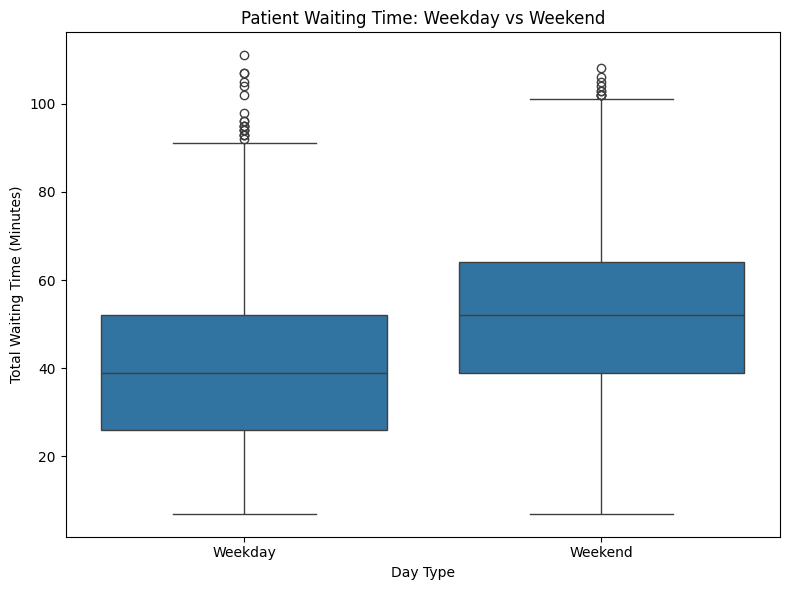

In [72]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Day_Type",
    y="Total_Waiting_Min"
)

plt.title("Patient Waiting Time: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Total Waiting Time (Minutes)")

plt.tight_layout()
plt.show()

VISUALIZATION 4 — Appointment Scheduling Congestion

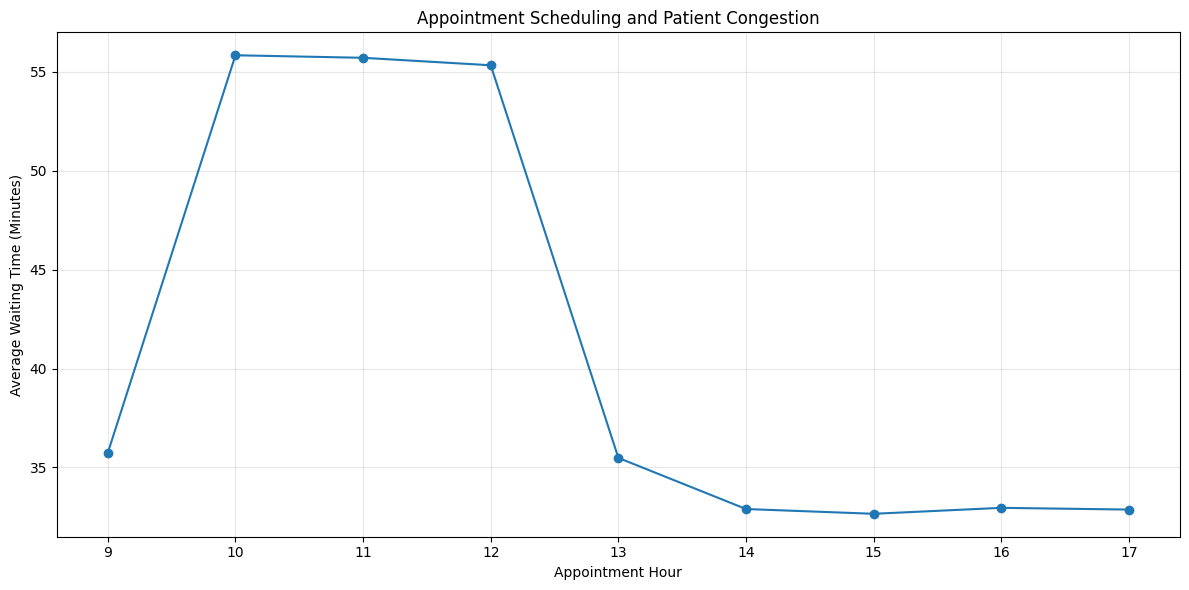

In [73]:
hour_plot = (
    df.groupby("Appointment_Hour")
    .agg(
        Patients=("Patient_ID", "count"),
        Avg_Waiting=("Total_Waiting_Min", "mean")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    hour_plot["Appointment_Hour"],
    hour_plot["Avg_Waiting"],
    marker="o"
)

ax1.set_xlabel("Appointment Hour")
ax1.set_ylabel(
    "Average Waiting Time (Minutes)"
)

ax1.set_title(
    "Appointment Scheduling and Patient Congestion"
)

ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [74]:
waiting_threshold = df["Total_Waiting_Min"].median()

df["High_Waiting"] = (
    df["Total_Waiting_Min"] >
    waiting_threshold
).astype(int)

print(
    "High waiting threshold:",
    waiting_threshold,
    "minutes"
)

print("\nTarget distribution:")
print(df["High_Waiting"].value_counts())

High waiting threshold: 43.0 minutes

Target distribution:
High_Waiting
0    5194
1    4806
Name: count, dtype: int64


In [75]:
features = [
    "Department",
    "Doctor",
    "Day",
    "Appointment_Type",
    "Appointment_Hour",
    "Appointment_Minute",
    "Day_Type"
]

X = df[features]

y = df["High_Waiting"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Department', 'Doctor', 'Day', 'Appointment_Type', 'Appointment_Hour', 'Appointment_Minute', 'Day_Type']

Target:
High_Waiting


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


In [77]:
categorical_features = [
    "Department",
    "Doctor",
    "Day",
    "Appointment_Type",
    "Day_Type"
]

numeric_features = [
    "Appointment_Hour",
    "Appointment_Minute"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [78]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model)
    ]
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [79]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("===== RANDOM FOREST RESULTS =====")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

===== RANDOM FOREST RESULTS =====
Accuracy  : 0.7975
Precision : 0.7797
Recall    : 0.8065
F1 Score  : 0.7928


In [80]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Normal Waiting",
            "High Waiting"
        ]
    )
)

                precision    recall  f1-score   support

Normal Waiting       0.82      0.79      0.80      1039
  High Waiting       0.78      0.81      0.79       961

      accuracy                           0.80      2000
     macro avg       0.80      0.80      0.80      2000
  weighted avg       0.80      0.80      0.80      2000



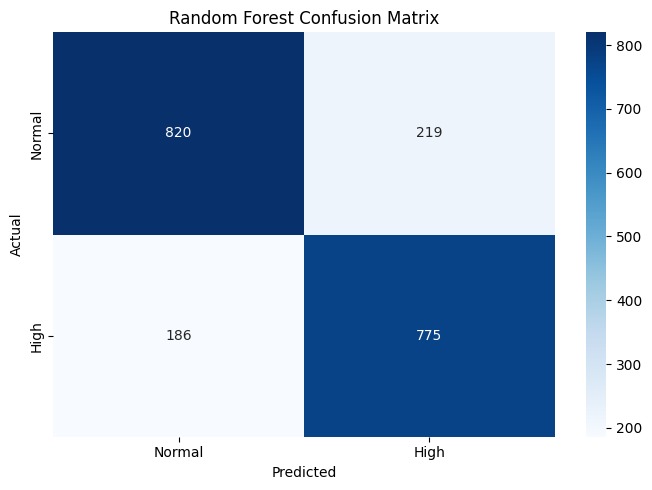

In [81]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Normal",
        "High"
    ],
    yticklabels=[
        "Normal",
        "High"
    ]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [82]:
feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    model.named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(15))

,Feature,Importance
37,numeric__Appointment_Hour,0.408872
38,numeric__Appointment_Minute,0.084167
31,categorical__Appointment_Type_Emergency,0.064178
34,categorical__Appointment_Type_Walk-in,0.062327
35,categorical__Day_Type_Weekday,0.041918
33,categorical__Appointment_Type_Regular,0.041144
36,categorical__Day_Type_Weekend,0.036440
32,categorical__Appointment_Type_Follow-up,0.034265
5,categorical__Department_Neurology,0.024425
1,categorical__Department_Dermatology,0.019969


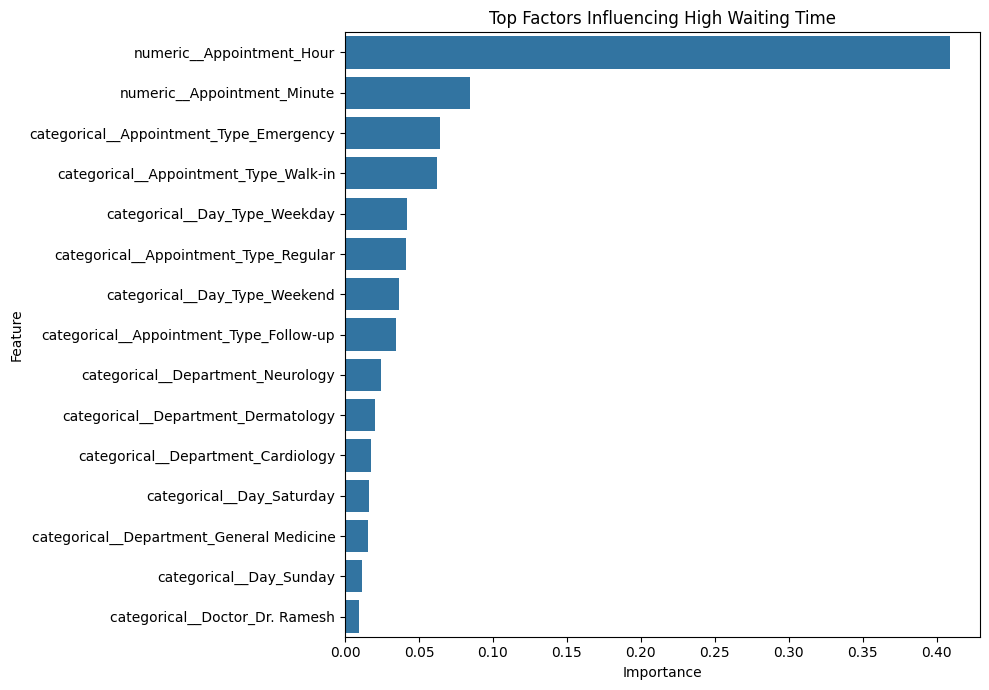

In [83]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Factors Influencing High Waiting Time"
)

plt.tight_layout()
plt.show()

In [84]:
highest_department = department_analysis.index[0]

highest_department_wait = department_analysis.iloc[0]["Avg_Total_Wait"]

highest_registration = department_analysis.sort_values(
    "Avg_Registration_Wait",
    ascending=False
).index[0]

highest_doctor_wait = department_analysis.sort_values(
    "Avg_Doctor_Wait",
    ascending=False
).index[0]

highest_appointment_type = appointment_analysis.index[0]

highest_hour = hour_analysis["Avg_Waiting"].idxmax()

weekday_wait = weekend_analysis.loc[
    "Weekday", "Avg_Total_Wait"
]

weekend_wait = weekend_analysis.loc[
    "Weekend", "Avg_Total_Wait"
]

print("========== KEY INSIGHTS ==========\n")

print(
    f"1. {highest_department} has the highest "
    f"average total waiting time "
    f"({highest_department_wait:.2f} minutes)."
)

print(
    f"2. {highest_registration} has the highest "
    f"average registration waiting time."
)

print(
    f"3. {highest_doctor_wait} has the highest "
    f"average doctor waiting time."
)

print(
    f"4. {highest_appointment_type} appointments "
    f"have the highest average waiting time."
)

print(
    f"5. Appointment hour {highest_hour}:00 "
    f"has the highest average waiting time."
)

print(
    f"6. Average weekday waiting time is "
    f"{weekday_wait:.2f} minutes, while weekend "
    f"waiting time is {weekend_wait:.2f} minutes."
)

print(
    f"7. The Random Forest model achieved "
    f"{accuracy*100:.2f}% accuracy in identifying "
    f"high-waiting patients."
)

========== KEY INSIGHTS ==========

1. Neurology has the highest average total waiting time (53.25 minutes).
2. Dermatology has the highest average registration waiting time.
3. Neurology has the highest average doctor waiting time.
4. Emergency appointments have the highest average waiting time.
5. Appointment hour 10:00 has the highest average waiting time.
6. Average weekday waiting time is 40.04 minutes, while weekend waiting time is 52.09 minutes.
7. The Random Forest model achieved 79.75% accuracy in identifying high-waiting patients.


In [85]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Training Score:", train_score)
print("Testing Score:", test_score)

print(f"\nTraining Accuracy: {train_score * 100:.2f}%")
print(f"Testing Accuracy: {test_score * 100:.2f}%")

Training Score: 0.8695
Testing Score: 0.7975

Training Accuracy: 86.95%
Testing Accuracy: 79.75%


In [88]:
df.to_csv("hospital_patient_waiting_times_cleaned.csv", index=False)
from google.colab import files

files.download("hospital_patient_waiting_times_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Department', 'Doctor',
                                                   'Day', 'Appointment_Type',
                                                   'Day_Type']),
                                                 ('numeric', 'passthrough',
                                                  ['Appointment_Hour',
                                                   'Appointment_Minute'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_estimators=200, random_state=42))])

In [90]:
import joblib

joblib.dump(model, "hospital_waiting_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [91]:
from google.colab import files

files.download("hospital_waiting_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>